In [49]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [29]:
df = pd.read_csv('Divar.csv')
df_class = pd.read_csv('iran_city_classification.csv')

C:\Users\Toranj\AppData\Local\Temp\ipykernel_23864\1810723204.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Divar.csv')


In [ ]:
df = df.merge(df_class ,  left_on='city_slug' , right_on='نام شهر' , how='left')

In [32]:
df = df.drop(columns='نام شهر')

In [33]:
df

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius,دسته‌بندی
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0,کلان‌شهر
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,کلان‌شهر
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,7.500000e+08,False,False,7.500000e+08,NaN,26000000.0,NaN,NaN,132.0,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN,کلان‌شهر
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,9.500000e+08,False,False,9.500000e+08,NaN,95000000.0,NaN,NaN,90.0,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,کلان‌شهر
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,کلان‌شهر
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,residential-sell,apartment-sell,kermanshah,NaN,2024-07-01 00:00:00,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,NaN,NaN,NaN,NaN,مقطوع,7.470000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,NaN,NaN,4.0,چهار,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.350235,47.083241,500.0,کلان‌شهر
999996,999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,مشاور املاک,نوساز \n\n تک واحدی\n\nشخصی ساز\n\nروف گا...,آپارتمان ۱۱۰ متری سعادت آباد دریا,مقطوع,45000000.0,NaN,rent_credit,NaN,NaN,مقطوع,1.000000e+09,True,True,1.000000e+09,3.000000e+09,45000000.0,100000.0,NaN,110.0,NaN,NaN,1.0,دو,NaN,NaN,NaN,True,True,

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 62 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   Unnamed: 0                  1000000 non-null  int64         
 1   cat2_slug                   1000000 non-null  str           
 2   cat3_slug                   999999 non-null   str           
 3   city_slug                   999998 non-null   str           
 4   neighborhood_slug           437139 non-null   str           
 5   created_at_month            1000000 non-null  datetime64[us]
 6   user_type                   288882 non-null   str           
 7   description                 1000000 non-null  str           
 8   title                       999946 non-null   str           
 9   rent_mode                   352994 non-null   str           
 10  rent_value                  351322 non-null   float64       
 11  rent_to_single              19 non-n

In [17]:
df.isna().sum() / len(df) * 100

Unnamed: 0                     0.0000
cat2_slug                      0.0000
cat3_slug                      0.0001
city_slug                      0.0002
neighborhood_slug             56.2861
                               ...   
rent_price_on_special_days    98.9537
rent_price_at_weekends        98.6449
location_latitude             34.4392
location_longitude            34.4392
location_radius               66.0301
Length: 61, dtype: float64

In [20]:
for i in df.columns:
    print(f"{i} : {df[i].isna().sum()}")

Unnamed: 0 : 0
cat2_slug : 0
cat3_slug : 1
city_slug : 2
neighborhood_slug : 562861
created_at_month : 0
user_type : 711118
description : 0
title : 54
rent_mode : 647006
rent_value : 648678
rent_to_single : 999981
rent_type : 896039
price_mode : 426394
price_value : 431654
credit_mode : 647006
credit_value : 647905
rent_credit_transform : 647015
transformable_price : 647106
transformable_credit : 647915
transformed_credit : 927591
transformable_rent : 648752
transformed_rent : 927591
land_size : 813604
building_size : 19606
deed_type : 746542
has_business_deed : 965321
floor : 458252
rooms_count : 154101
total_floors_count : 695648
unit_per_floor : 697717
has_balcony : 493589
has_elevator : 458251
has_warehouse : 271845
has_parking : 271844
construction_year : 184172
is_rebuilt : 470530
has_water : 966556
has_warm_water_provider : 620500
has_electricity : 966555
has_gas : 966570
has_heating_system : 631031
has_cooling_system : 649381
has_restroom : 593087
has_security_guard : 968688
ha

In [84]:
df['cat3_slug'].value_counts()

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64

In [89]:
df[df['category'] == 'sell']

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius,category
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,sell
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sell
7,7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,NaN,NaN,NaN,مقطوع,8.700000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,4,دو,NaN,NaN,NaN,True,True,True,۱۳۹۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0,sell
8,8,residential-sell,apartment-sell,mahdasht-city,NaN,2024-06-01,مشاور املاک,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,NaN,NaN,NaN,NaN,مقطوع,6.500000e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.0,single_page,NaN,4,دو,6,4,true,True,True,True,۱۳۹۶,True,NaN,package,NaN,NaN,shoofaj,water_cooler,squat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,500.0,sell
9,9,residential-sell,apartment-sell,mashhad,faramarzabbasi,2024-10-01,NaN,اول رسالت فرد نزدیک به حاشیه فرامرز .. ساکنین...,متراژ ۸۰ متر فرامرز نزدیک حاشیه,NaN,NaN,NaN,NaN,مقطوع,3.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,3,دو,NaN,NaN,true,False,False,True,۱۳۸۷,False,NaN,NaN,NaN,NaN,NaN,NaN,squat,NaN,NaN,NaN,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999990,999990,residential-sell,apartment-sell,urmia,NaN,2024-09-01,مشاور املاک,➖➖➖➖➖⚜️ املاک مهندس ⚜️➖➖➖➖➖\n\nواحد آپارتمان ...,آپارتمان تک واحدی / آبشناسان/ وام تا سقف ۱.۱۰۰,NaN,NaN,NaN,NaN,مقطوع,4.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140.0,NaN,NaN,1.0,دو,NaN,NaN,NaN,True,True,True,۱۴۰۱,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.505325,45.050369,500.0,sell
999991,999991,residential-sell,apartment-sell,tehran,shaharak-e-moslemin,2024-12-01,NaN,بنام ایزد منان\n ۹۱ متر ۲ خواب خوش نقشه \nنورگ...,آپارتمان ۹۱متر ۲ خواب/شهرک صاحب الزمان,NaN,NaN,NaN,NaN,مقطوع,3.600000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.0,single_page,NaN,4.0,دو,4.0,2,False,False,True,True,۱۳۸۸,True,NaN,water_heater,NaN,NaN,heater,water_cooler

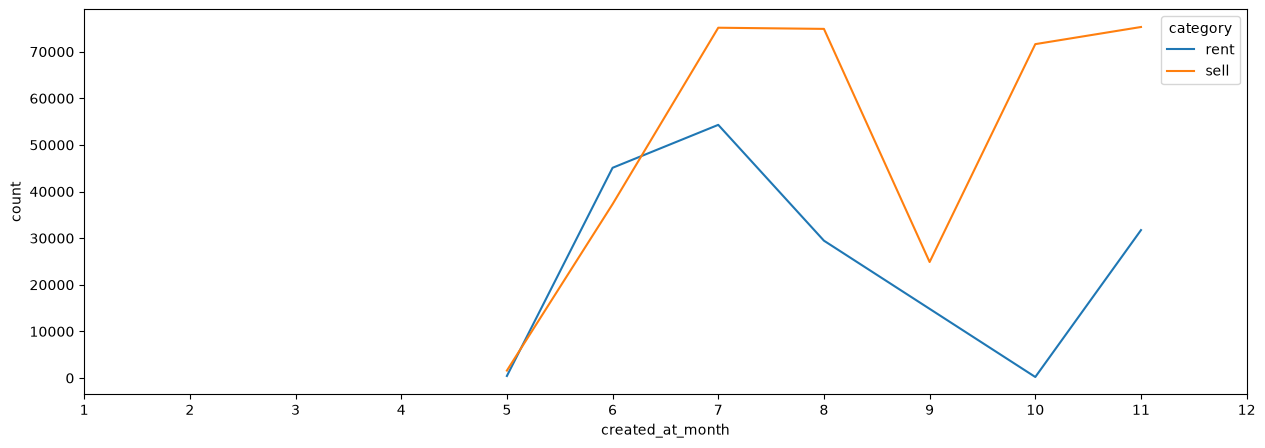

In [13]:
df['category'] = df['cat2_slug'].str.extract('(rent|sell)')
df['created_at_month'] = pd.to_datetime(df['created_at_month'])
count = df.groupby([df['created_at_month'].dt.month , 'category']).size().reset_index(name='count')

fig , ax = plt.subplots(figsize=(15,5))
sns.lineplot(data=count , x=df['created_at_month'].dt.month , y='count' , hue='category' , errorbar=None)
plt.xticks(range(1, 13))
plt.show()

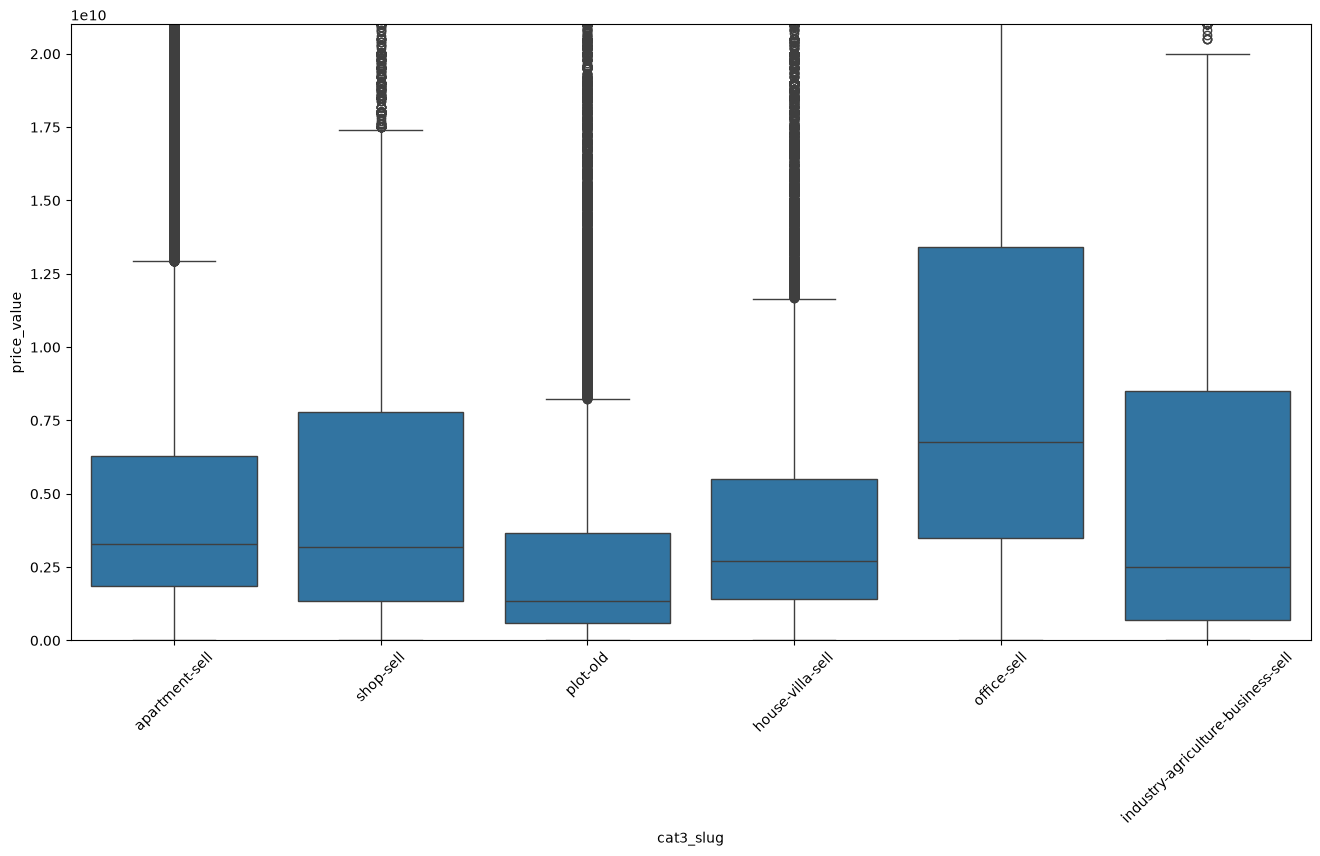

In [12]:
sell_df = df[df['category'] == 'sell'].copy()
sell_df['price_value'] = pd.to_numeric(sell_df['price_value'] , errors='coerce')
upper = sell_df['price_value'].quantile(0.95)


plt.figure(figsize=(16, 8))
sns.boxplot(data=sell_df , x='cat3_slug' , y='price_value')
plt.ylim(0, upper)
plt.xticks(rotation=45)
plt.xlabel('cat3_slug')
plt.ylabel('price_value')
plt.show()

In [35]:
df

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_water,has_warm_water_provider,has_electricity,has_gas,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius,دسته‌بندی
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,NaN,سه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0,کلان‌شهر
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,NaN,3,یک,NaN,NaN,NaN,True,True,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,کلان‌شهر
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,7.500000e+08,False,False,7.500000e+08,NaN,26000000.0,NaN,NaN,132.0,NaN,NaN,3,سه,NaN,NaN,NaN,True,True,True,۱۴۰۱,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN,کلان‌شهر
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,9.500000e+08,False,False,9.500000e+08,NaN,95000000.0,NaN,NaN,90.0,NaN,NaN,4,یک,NaN,NaN,NaN,True,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,کلان‌شهر
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.0,single_page,NaN,4,دو,6,NaN,true,True,True,True,۱۴۰۳,NaN,NaN,package,NaN,NaN,shoofaj,air_conditioner,squat_seat,NaN,NaN,north,NaN,NaN,NaN,ceramic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,کلان‌شهر
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999995,residential-sell,apartment-sell,kermanshah,NaN,2024-07-01 00:00:00,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,NaN,NaN,NaN,NaN,مقطوع,7.470000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,NaN,NaN,4.0,چهار,NaN,NaN,NaN,True,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.350235,47.083241,500.0,کلان‌شهر
999996,999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,مشاور املاک,نوساز \n\n تک واحدی\n\nشخصی ساز\n\nروف گا...,آپارتمان ۱۱۰ متری سعادت آباد دریا,مقطوع,45000000.0,NaN,rent_credit,NaN,NaN,مقطوع,1.000000e+09,True,True,1.000000e+09,3.000000e+09,45000000.0,100000.0,NaN,110.0,NaN,NaN,1.0,دو,NaN,NaN,NaN,True,True,

In [52]:
Q1 = df['building_size'].quantile(0.25)
Q3 = df['building_size'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_normal = df[(df['building_size'] >= lower) & (df['building_size'] <= upper)]

In [53]:
big_cities = df_normal[df_normal['دسته‌بندی'] == 'کلان‌شهر']['building_size'].dropna()
small_cities = df_normal[df_normal['دسته‌بندی'] == 'شهر کوچک']['building_size'].dropna()

t_stat, p_value = ttest_ind(big_cities , small_cities , equal_var=False , alternative='less')

print('Metro mean:', big_cities.mean())
print('Small mean:', small_cities.mean())
print('t-statistic:', t_stat)
print('p-value:', p_value)

Metro mean: 105.78480441728743
Small mean: 114.02356525319061
t-statistic: -64.62808414970104
p-value: 0.0


In [54]:
print(big_cities.describe())
print(small_cities.describe())

count    421254.000000
mean        105.784804
std          55.309665
min           1.000000
25%          68.000000
50%          95.000000
75%         131.000000
max         300.000000
Name: building_size, dtype: float64
count    425075.000000
mean        114.023565
std          61.814275
min           1.000000
25%          75.000000
50%         100.000000
75%         142.000000
max         300.000000
Name: building_size, dtype: float64


In [55]:

u_stat, p_value = mannwhitneyu(big_cities , small_cities , alternative='less')
print('U statistic:', u_stat)
print('p-value:', p_value)

U statistic: 83409861392.0
p-value: 0.0
